# Решение домашнего задания #22

[задача](../../tasks/hometask_22.ipynb)

In [ ]:
from pathlib import Path
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import torchvision.transforms as transforms
from torchvision.models import maxvit_t, MaxVit_T_Weights

import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, hamming_loss, jaccard_score

import matplotlib.pyplot as plt

from tqdm import tqdm

import kagglehub

from PIL import Image

from nndcg import neuralNDCG


torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = 'cpu'
print(f"Using device: {device}")

## Реализация NeuralNDCG Loss

NeuralNDCG - это дифференцируемая аппроксимация метрики NDCG (Normalized Discounted Cumulative Gain), которая позволяет оптимизировать ранжирование напрямую через градиентный спуск.

In [2]:
class NeuralNDCG(nn.Module):
    """
    NeuralNDCG loss implementation for multilabel classification.
    """
    def __init__(self, temperature=1.0, k=None):
        super().__init__()
        self.temperature = temperature
        self.k = k  # Top-k elements to consider in NDCG calculation
        
    def forward(self, logits, labels):
        """
        Args:
            logits: tensor of shape (batch_size, num_classes) - model predictions
            labels: tensor of shape (batch_size,) - true labels
        """
        return neuralNDCG(torch.sigmoid(logits), labels, temperature=self.temperature, k=self.k)


class CombinedLoss(nn.Module):
    """
    Combined loss of BCE and NeuralNDCG.
    """
    def __init__(self, alpha=0.5, temperature=1.0, k=None):
        super().__init__()
        self.alpha = alpha
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.ndcg_loss = NeuralNDCG(temperature=temperature, k=k)
        
    def forward(self, logits, labels):
        bce = self.bce_loss(logits, labels)
        ndcg = self.ndcg_loss(logits, labels)
        return self.alpha * bce + (1 - self.alpha) * ndcg, bce, ndcg

## Загрузка данных

Используем датасет "meherunnesashraboni/multi-label-image-classification-dataset" - мультиклассовый датасет изображений различных объектов с 7K сэмплами и множественными метками.

In [ ]:
print("Loading dataset...")
dataset_path = Path(kagglehub.dataset_download("meherunnesashraboni/multi-label-image-classification-dataset")) / "multilabel_modified"
dataset_image_path = dataset_path / "images"
dataset_label_path = dataset_path / "multilabel_classification(7).csv"

dataset = []
all_labels = set()
with open(dataset_label_path) as f:
    for i, line in tqdm(enumerate(f)):
        if line.startswith(("Image_Name,", "Column1,")):
            continue
    
        image_name, labels = line.split(',')

        labels = labels.split()
        try:
            with Image.open(dataset_image_path / image_name) as img:
                image = img.copy().convert('RGB')
        except:
            print(line)
            continue

        all_labels.update(labels)
        dataset.append((image, labels))
        
random.shuffle(dataset)

classes = sorted(list(all_labels))
num_classes = len(classes)
label_to_idx = {label: idx for idx, label in enumerate(classes)}

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Loading dataset from HuggingFace...


7944it [00:50, 158.23it/s]

Number of classes: 10
Classes: ['boat', 'bus', 'cycle', 'ektara', 'flutes', 'harmonium', 'motorcycle', 'sitar', 'tabla', 'truck']


In [4]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Custom dataset for multilabel data
class MultilabelGeoSceneDataset(Dataset):
    def __init__(self, hf_dataset, split='train', transform=None, label_to_idx=None, num_classes=None):
        self.dataset = hf_dataset
        self.split = split
        self.transform = transform
        self.label_to_idx = label_to_idx
        self.num_classes = num_classes

        self.split_start = 0 if split == 'train' else int(0.9 * len(self.dataset))
        self.split_end = int(0.9 * len(self.dataset)) if split == 'train' else len(self.dataset)
        
    def __len__(self):
        return self.split_end - self.split_start
    
    def __getitem__(self, idx):
        image, labels = self.dataset[idx + self.split_start]
        
        if self.transform:
            image = self.transform(image)
        
        # Create multilabel target (binary vector)
        target = torch.zeros(self.num_classes)
        for label in labels:
            if label in self.label_to_idx:
                target[self.label_to_idx[label]] = 1
        
        return image, target

trainset = MultilabelGeoSceneDataset(
    dataset,
    split='train',
    transform=transform_train,
    label_to_idx=label_to_idx,
    num_classes=num_classes
)
testset = MultilabelGeoSceneDataset(
    dataset,
    split='test',
    transform=transform_test,
    label_to_idx=label_to_idx,
    num_classes=num_classes
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=32)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=32)

print(f"Training samples: {len(trainset)}, Test samples: {len(testset)}")

Training samples: 7148, Test samples: 795


## Этап 1: Извлечение признаков

Используем предобученный MaxVit для извлечения визуальных признаков из изображений.

In [5]:
class FeatureExtractor(nn.Module):
    """MaxViT for feature extraction (without the final classification layer)"""
    def __init__(self):
        super().__init__()
        self.maxvit_model = maxvit_t(weights=MaxVit_T_Weights.IMAGENET1K_V1)
        # Remove the last fully connected layer
        self.maxvit_model.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        
    def forward(self, x):
        return self.maxvit_model(x)

feature_extractor = FeatureExtractor().to(device)
feature_extractor.eval()  # Freeze parameters

output_sample = feature_extractor(torch.randn(1, 3, 224, 224).to(device))
feature_dim = output_sample.size(1)
print(f"Feature dimension: {feature_dim}")

Feature dimension: 512


In [6]:
def extract_features(dataloader, extractor):
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            features = extractor(images)
            features_list.append(features.cpu())
            labels_list.append(labels)
    
    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return features, labels

train_features, train_labels = extract_features(trainloader, feature_extractor)
test_features, test_labels = extract_features(testloader, feature_extractor)

print(f"Train features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")

Extracting features: 100%|██████████| 7/7 [00:08<00:00,  1.27s/it]

Train features shape: torch.Size([7148, 512])
Test features shape: torch.Size([795, 512])


## Этап 2: Классификатор на основе признаков

Построим простой Transformer-based классификатор поверх извлеченных признаков.

In [ ]:
class TransformerClassifier(nn.Module):
    """
    Classifier based on Transformer on top of extracted features for multilabel classification
    """
    def __init__(self, input_dim=512, num_classes=10, hidden_dim=256, num_heads=8, num_layers=2):
        super().__init__()
        
        # Input feature projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head for multilabel
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x.unsqueeze(1))
        logits = self.classifier(x.squeeze(1))
        return logits

In [ ]:
class FeaturesDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_feature_dataset = FeaturesDataset(train_features, train_labels)
test_feature_dataset = FeaturesDataset(test_features, test_labels)

train_feature_loader = DataLoader(train_feature_dataset, batch_size=128, shuffle=True)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=128, shuffle=False)

## Функции обучения и оценки

In [ ]:
def train_model(model, train_loader, test_loader, criterion, num_epochs=40, lr=1e-3, limit_steps = 3):
    """Model training loop for multilabel classification"""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'train_bce': [],
        'train_ndcg': []
    }
    
    best_acc = 0.0
    best_state_dict = None
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_bce_loss = 0.0
        train_ndcg_loss = 0.0
        correct_labels = 0
        total_labels = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for step, (features, labels) in enumerate(pbar):
            if step >= limit_steps:
                break
            
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(features)
            
            # Calculate loss
            if isinstance(criterion, CombinedLoss):
                loss, bce, ndcg = criterion(outputs, labels)
                train_bce_loss += bce.item()
                train_ndcg_loss += ndcg.item()
            else:
                loss = criterion(outputs, labels)
                train_bce_loss += loss.item()
                train_ndcg_loss += 0
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # For multilabel accuracy: use threshold 0.5
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_labels += (predicted == labels).sum().item()
            total_labels += labels.numel()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct_labels/total_labels:.2f}%'})
        
        train_acc = 100. * correct_labels / total_labels
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['train_bce'].append(train_bce_loss / len(train_loader))
        history['train_ndcg'].append(train_ndcg_loss / len(train_loader))
        
        # Evaluation
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_state_dict = model.state_dict()

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    return history, best_acc

In [ ]:
def evaluate_model(model, test_loader, criterion):
    """Model evaluation for multilabel classification"""
    model.eval()
    test_loss = 0.0
    correct_labels = 0
    total_labels = 0
    
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            
            if isinstance(criterion, CombinedLoss):
                loss, _, _ = criterion(outputs, labels)
            else:
                loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            
            # For multilabel accuracy: use threshold 0.5
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_labels += (predicted == labels).sum().item()
            total_labels += labels.numel()
    
    test_acc = 100. * correct_labels / total_labels
    test_loss = test_loss / len(test_loader)
    
    return test_loss, test_acc

In [ ]:
def get_predictions(model, test_loader):
    """Get model predictions for all data (multilabel)"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            outputs = model(features)
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            
            all_preds.append(predicted.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    return np.vstack(all_preds), np.vstack(all_labels), np.vstack(all_probs)

## Эксперимент 1: Обучение с обычной BCE Loss (для multilabel)

In [9]:
model_bce = TransformerClassifier(input_dim=feature_dim, num_classes=num_classes).to(device)
criterion_bce = nn.BCEWithLogitsLoss()

# Train the model with BCE loss
history_bce, best_acc_bce = train_model(
    model_bce, 
    train_feature_loader, 
    test_feature_loader, 
    criterion_bce,
)

print(f"\nBest test accuracy (BCE): {best_acc_bce:.2f}%")

Epoch 1/40:   5%|▌         | 3/56 [00:00<00:04, 11.72it/s, loss=0.4209, acc=74.56%]


Epoch 1: Train Loss: 0.0293, Train Acc: 74.56%, Test Acc: 87.82%


Epoch 2/40:   5%|▌         | 3/56 [00:00<00:00, 84.51it/s, loss=0.3270, acc=88.33%]


Epoch 2: Train Loss: 0.0187, Train Acc: 88.33%, Test Acc: 88.01%


Epoch 3/40:   5%|▌         | 3/56 [00:00<00:00, 90.29it/s, loss=0.2730, acc=89.35%]


...

Epoch 38: Train Loss: 0.0013, Train Acc: 99.45%, Test Acc: 99.46%


Epoch 39/40:   5%|▌         | 3/56 [00:00<00:00, 89.31it/s, loss=0.0336, acc=99.40%]


Epoch 39: Train Loss: 0.0015, Train Acc: 99.40%, Test Acc: 99.46%


Epoch 40/40:   5%|▌         | 3/56 [00:00<00:00, 94.91it/s, loss=0.0173, acc=99.51%]


Epoch 40: Train Loss: 0.0009, Train Acc: 99.51%, Test Acc: 99.46%

Best test accuracy (BCE): 99.48%


## Эксперимент 2: Обучение с комбинированной потерей (BCE + NeuralNDCG)

In [10]:
model_ndcg = TransformerClassifier(input_dim=feature_dim, num_classes=num_classes).to(device)
criterion_ndcg = CombinedLoss(alpha=0.5, temperature=1.0, k=5)

# Train the model with combined loss
history_ndcg, best_acc_ndcg = train_model(
    model_ndcg, 
    train_feature_loader, 
    test_feature_loader, 
    criterion_ndcg,
)

print(f"\nBest test accuracy (BCE + NeuralNDCG): {best_acc_ndcg:.2f}%")

Epoch 1/40:   5%|▌         | 3/56 [00:00<00:08,  6.59it/s, loss=-0.0332, acc=71.33%]


Epoch 1: Train Loss: 0.0038, Train Acc: 71.33%, Test Acc: 92.91%


Epoch 2/40:   5%|▌         | 3/56 [00:00<00:02, 25.56it/s, loss=-0.1952, acc=93.78%]


Epoch 2: Train Loss: -0.0085, Train Acc: 93.78%, Test Acc: 95.99%


Epoch 3/40:   5%|▌         | 3/56 [00:00<00:02, 25.28it/s, loss=-0.2717, acc=96.41%]


...

Epoch 38: Train Loss: -0.0233, Train Acc: 99.61%, Test Acc: 99.42%


Epoch 39/40:   5%|▌         | 3/56 [00:00<00:02, 18.28it/s, loss=-0.4342, acc=99.58%]


Epoch 39: Train Loss: -0.0234, Train Acc: 99.58%, Test Acc: 99.42%


Epoch 40/40:   5%|▌         | 3/56 [00:00<00:02, 17.96it/s, loss=-0.4312, acc=99.32%]


Epoch 40: Train Loss: -0.0230, Train Acc: 99.32%, Test Acc: 99.42%

Best test accuracy (BCE + NeuralNDCG): 99.42%


## Визуализация результатов

Теперь сравним производительность двух моделей.

In [ ]:
preds_bce, labels_true, probs_bce = get_predictions(model_bce, test_feature_loader)
preds_ndcg, _, probs_ndcg = get_predictions(model_ndcg, test_feature_loader)

true_counts = labels_true.sum(axis=1)
pred_counts_bce = preds_bce.sum(axis=1)
pred_counts_ndcg = preds_ndcg.sum(axis=1)

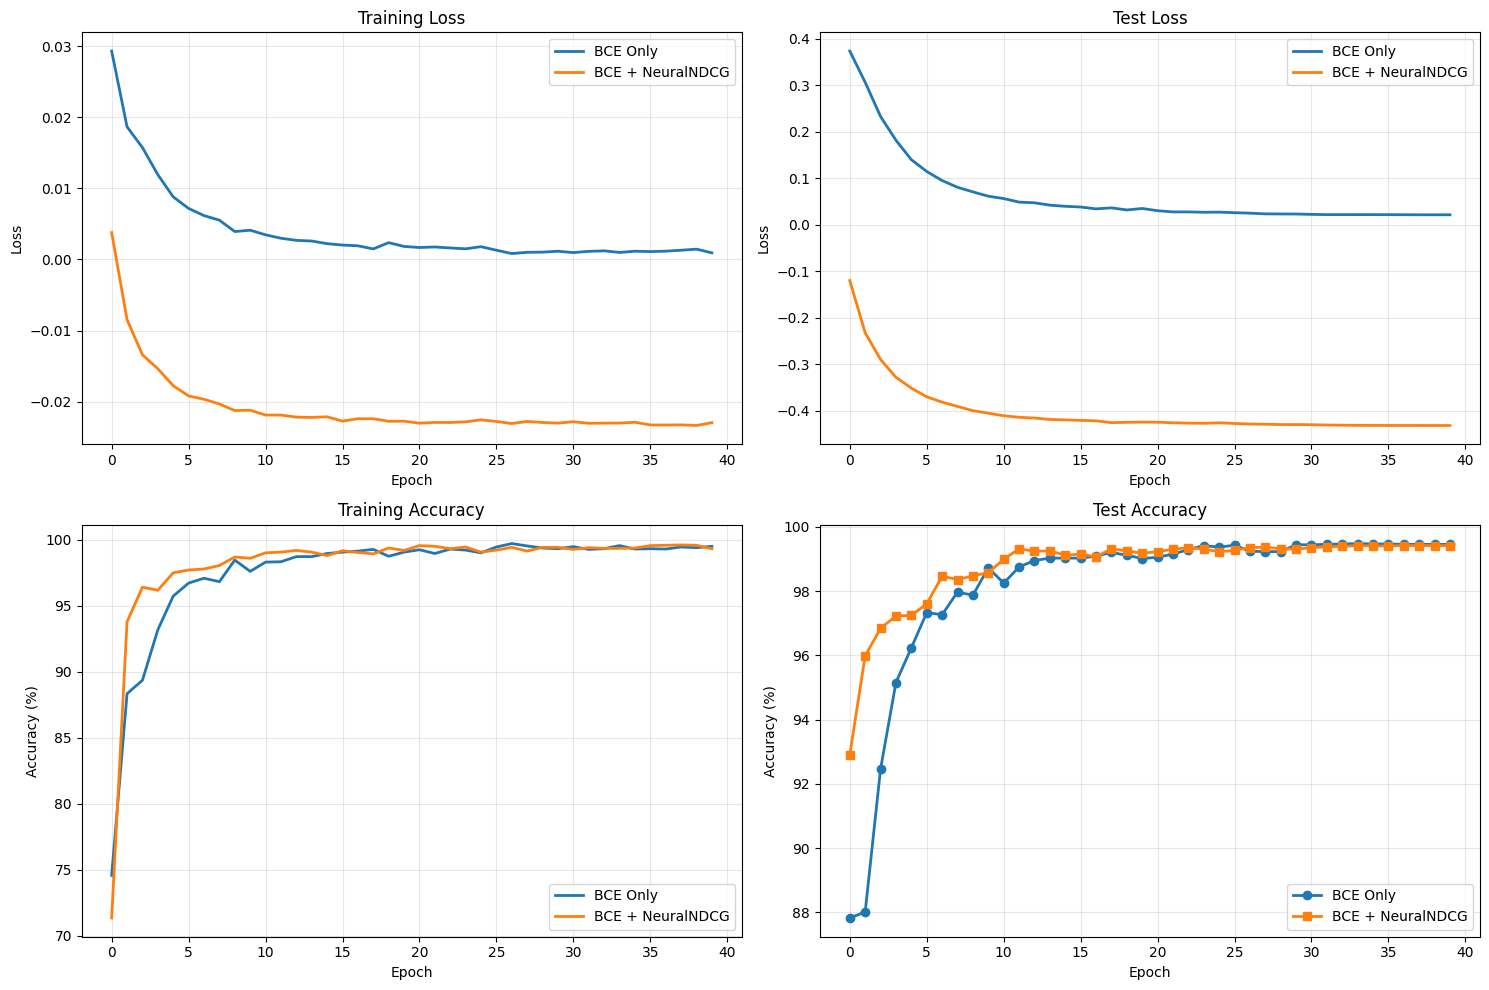

Final test accuracy:
  BCE Only: 99.48%
  BCE + NeuralNDCG: 99.42%
  Improvement: -0.06%


In [11]:
# Plotting training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Train Loss
axes[0, 0].plot(history_bce['train_loss'], label='BCE Only', linewidth=2)
axes[0, 0].plot(history_ndcg['train_loss'], label='BCE + NeuralNDCG', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test Loss
axes[0, 1].plot(history_bce['test_loss'], label='BCE Only', linewidth=2)
axes[0, 1].plot(history_ndcg['test_loss'], label='BCE + NeuralNDCG', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Test Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Train Accuracy
axes[1, 0].plot(history_bce['train_acc'], label='BCE Only', linewidth=2)
axes[1, 0].plot(history_ndcg['train_acc'], label='BCE + NeuralNDCG', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Training Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test Accuracy
axes[1, 1].plot(history_bce['test_acc'], label='BCE Only', linewidth=2, marker='o')
axes[1, 1].plot(history_ndcg['test_acc'], label='BCE + NeuralNDCG', linewidth=2, marker='s')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Test Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final test accuracy:")
print(f"  BCE Only: {best_acc_bce:.2f}%")
print(f"  BCE + NeuralNDCG: {best_acc_ndcg:.2f}%")
print(f"  Improvement: {best_acc_ndcg - best_acc_bce:+.2f}%")

Не смотря на то, что результаты очень схожи, но при этом динамика обучения у ndcg_loss более стабильная, а качество на ранних шагах сильнее.

_PS: более длинное обучение (20 эпох без лимита на шаги) показывает, что ndcg_loss обганяет BCE на 0.2%_

## Детальный анализ: Per-Class Performance


Comparison of per-class metrics (Multilabel)
     Class  BCE_Precision  NDCG_Precision  BCE_Recall  NDCG_Recall    BCE_F1   NDCG_F1  Samples  F1_Improvement
      boat     100.000000      100.000000   96.428571    97.023810 98.181818 98.489426      168        0.307608
       bus      98.333333       98.275862   96.721311    93.442623 97.520661 95.798319       61       -1.722342
     cycle      99.236641       98.518519   97.014925    99.253731 98.113208 98.884758      134        0.771551
    ektara      94.444444       91.891892  100.000000   100.000000 97.142857 95.774648       34       -1.368209
    flutes     100.000000      100.000000   98.412698    98.412698 99.200000 99.200000       63        0.000000
 harmonium     100.000000       98.666667   96.153846    94.871795 98.039216 96.732026       78       -1.307190
motorcycle      97.600000       96.825397   98.387097    98.387097 97.991968 97.600000      124       -0.391968
     sitar      97.500000       97.560976   92.857143    9

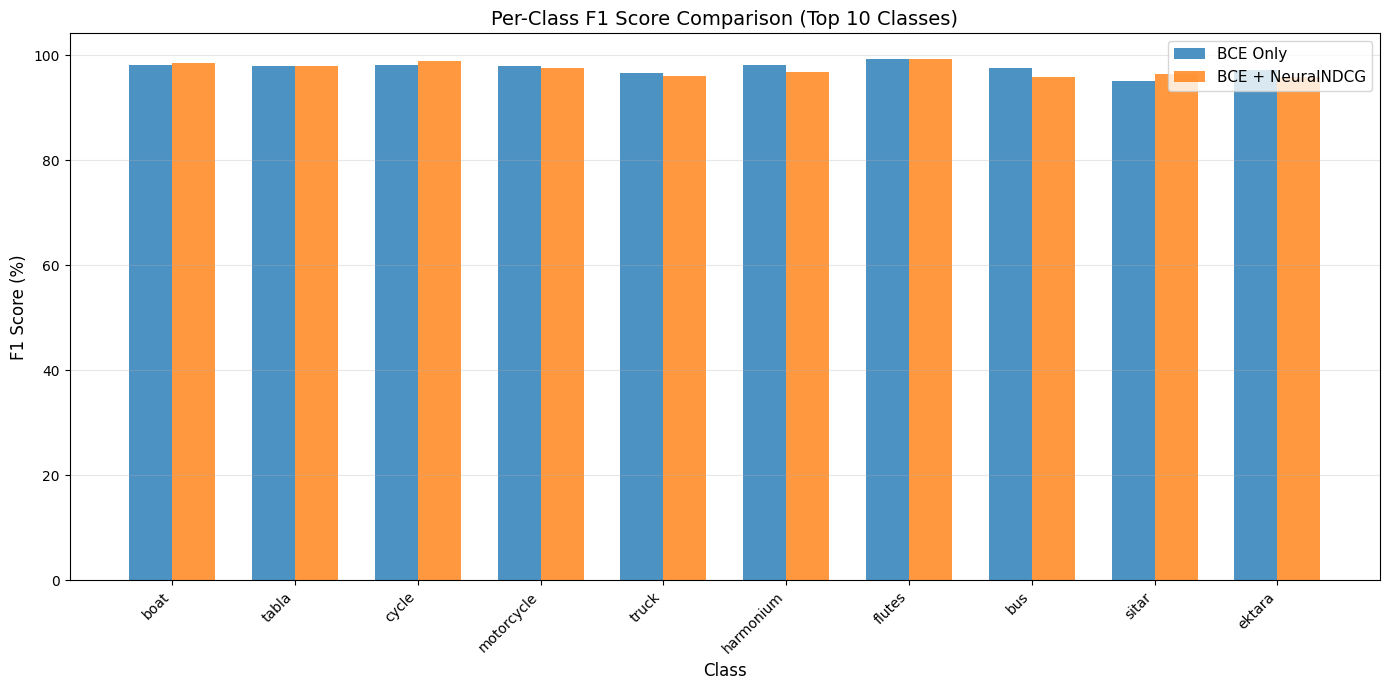

In [14]:
precision_bce, recall_bce, f1_bce, support = precision_recall_fscore_support(
    labels_true, preds_bce, average=None, zero_division=0
)
precision_ndcg, recall_ndcg, f1_ndcg, _ = precision_recall_fscore_support(
    labels_true, preds_ndcg, average=None, zero_division=0
)

# Create a DataFrame for better visualization
results_df = pd.DataFrame({
    'Class': classes,
    'BCE_Precision': precision_bce * 100,
    'NDCG_Precision': precision_ndcg * 100,
    'BCE_Recall': recall_bce * 100,
    'NDCG_Recall': recall_ndcg * 100,
    'BCE_F1': f1_bce * 100,
    'NDCG_F1': f1_ndcg * 100,
    'Samples': support
})

# Calculate improvements
results_df['F1_Improvement'] = results_df['NDCG_F1'] - results_df['BCE_F1']

print("\n" + "="*100)
print("Comparison of per-class metrics (Multilabel)")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Overall multilabel metrics
hamming_bce = hamming_loss(labels_true, preds_bce)
hamming_ndcg = hamming_loss(labels_true, preds_ndcg)
jaccard_bce = jaccard_score(labels_true, preds_bce, average='samples')
jaccard_ndcg = jaccard_score(labels_true, preds_ndcg, average='samples')

print(f"\nOverall multilabel metrics:")
print(f"  Hamming Loss (BCE): {hamming_bce:.4f}")
print(f"  Hamming Loss (BCE+NDCG): {hamming_ndcg:.4f}")
print(f"  Jaccard Score (BCE): {jaccard_bce:.4f}")
print(f"  Jaccard Score (BCE+NDCG): {jaccard_ndcg:.4f}")

# Visualization of per-class F1 scores (showing top 20 classes)
top_n = min(20, len(classes))
sorted_indices = np.argsort(support)[::-1][:top_n]
top_classes = [classes[i] for i in sorted_indices]

fig, ax = plt.subplots(1, 1, figsize=(14, 7))

x = np.arange(len(top_classes))
width = 0.35

bars1 = ax.bar(x - width/2, results_df.iloc[sorted_indices]['BCE_F1'], width, label='BCE Only', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df.iloc[sorted_indices]['NDCG_F1'], width, label='BCE + NeuralNDCG', alpha=0.8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title(f'Per-Class F1 Score Comparison (Top {top_n} Classes)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_classes, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

По полученным данным можно понять, что результат ndcg_loss не зависит от размеров классов. Однако хорошо видно, что для него упал Precision, а Recall вырос, что говорит о том, что модель в целом стала чаще предсказывать положительный класс.

Также стоит отметить, что просадки по `F1` в среднем выше, чем улучшения.

## Анализ уверенности предсказаний для multilabel (Confidence Analysis)

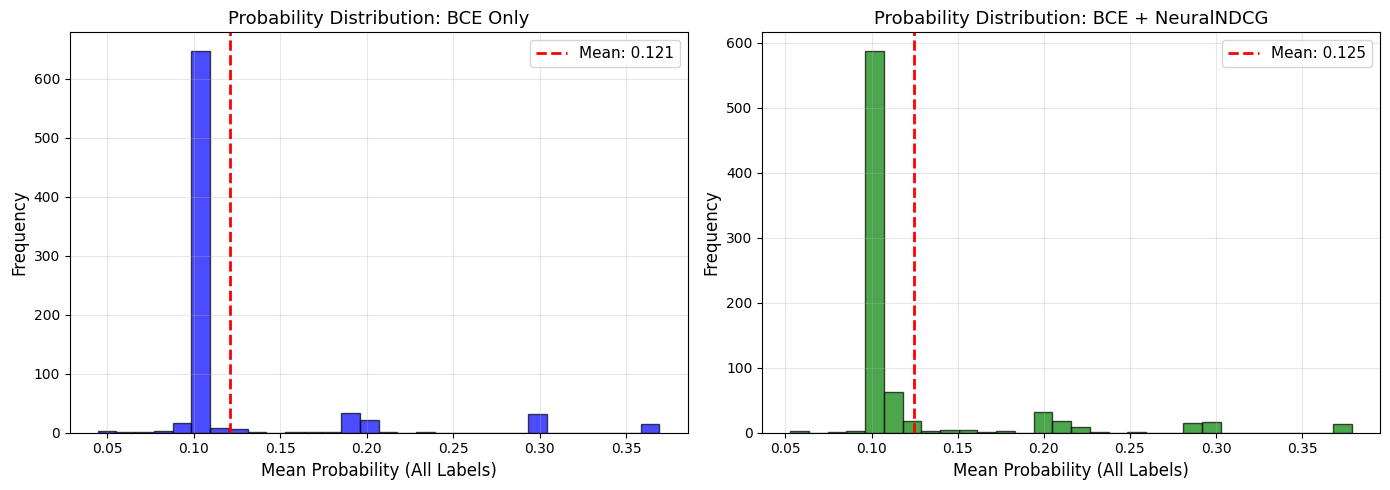


Confidence statistics for predictions
BCE Only:
  Mean probability (all labels): 0.1210
  Mean probability (positive predictions): 0.9675
  Std probability (all labels): 0.0564

BCE + NeuralNDCG:
  Mean probability (all labels): 0.1248
  Mean probability (positive predictions): 0.9773
  Std probability (all labels): 0.0568


In [15]:
mean_probs_bce = probs_bce.mean(axis=1)
mean_probs_ndcg = probs_ndcg.mean(axis=1)

# Mean probability only for predicted positive labels
positive_probs_bce = []
positive_probs_ndcg = []

for i in range(len(preds_bce)):
    if preds_bce[i].sum() > 0:
        positive_probs_bce.append(probs_bce[i][preds_bce[i] == 1].mean())
    if preds_ndcg[i].sum() > 0:
        positive_probs_ndcg.append(probs_ndcg[i][preds_ndcg[i] == 1].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of mean probabilities for BCE
axes[0].hist(mean_probs_bce, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Mean Probability (All Labels)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Probability Distribution: BCE Only', fontsize=13)
axes[0].axvline(np.mean(mean_probs_bce), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mean_probs_bce):.3f}')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Distribution of mean probabilities for NDCG
axes[1].hist(mean_probs_ndcg, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Mean Probability (All Labels)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Probability Distribution: BCE + NeuralNDCG', fontsize=13)
axes[1].axvline(np.mean(mean_probs_ndcg), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mean_probs_ndcg):.3f}')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Confidence statistics for positive predictions
print("\n" + "="*60)
print("Confidence statistics for predictions")
print("="*60)
print(f"BCE Only:")
print(f"  Mean probability (all labels): {np.mean(mean_probs_bce):.4f}")
print(f"  Mean probability (positive predictions): {np.mean(positive_probs_bce):.4f}")
print(f"  Std probability (all labels): {np.std(mean_probs_bce):.4f}")
print(f"\nBCE + NeuralNDCG:")
print(f"  Mean probability (all labels): {np.mean(mean_probs_ndcg):.4f}")
print(f"  Mean probability (positive predictions): {np.mean(positive_probs_ndcg):.4f}")
print(f"  Std probability (all labels): {np.std(mean_probs_ndcg):.4f}")
print("="*60)

Хорошо заметно, что ndcg_loss увеличил уверенность предсказаний, что подтверждает предыдущие наблюдения. В целом, это веьма ожидаемый результат, так как чем неуверенее модель, тем чаще она может получить большой пенальти из-за случайно перепутанных рангов.

## Top-K Label Prediction Analysis для Multilabel

NeuralNDCG оптимизирует ранжирование меток. Давайте проверим, насколько точно модели ранжируют правильные метки в топ позиций.


Top-K Recall Comparison (Multilabel)
 K  BCE_TopK_Recall  NDCG_TopK_Recall  Improvement
 1        90.503143         90.377357    -0.125786
 2        96.855347         96.729561    -0.125786
 3        99.182388         99.371071     0.188683
 5        99.874214        100.000000     0.125786


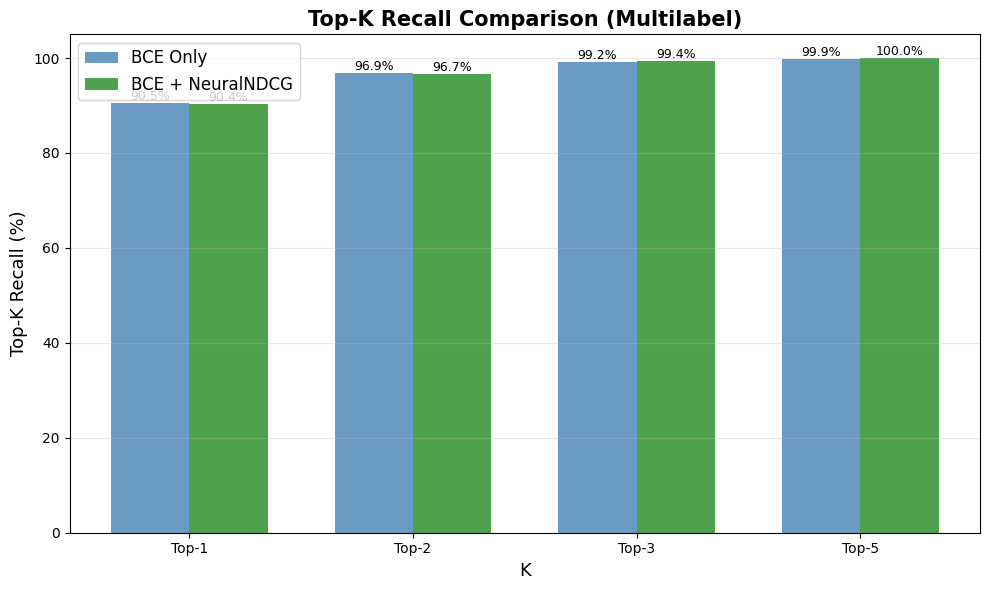

In [19]:
def compute_topk_recall_multilabel(probs, labels, k_values=[3, 5, 10]):
    """
    Вычисляет Top-K recall для multilabel классификации.
    Для каждого примера берем top-K предсказаний и проверяем, сколько истинных меток попало в top-K.
    """
    results = {}
    for k in k_values:
        recalls = []
        for i in range(len(probs)):
            # Берем индексы top-k предсказаний по вероятности
            top_k_indices = np.argsort(probs[i])[-k:]
            
            # Создаем binary вектор для top-k предсказаний
            top_k_pred = np.zeros_like(labels[i])
            top_k_pred[top_k_indices] = 1
            
            # Вычисляем recall: сколько истинных меток попало в top-k
            true_labels = labels[i]
            if true_labels.sum() > 0:  # Если есть истинные метки
                recall = (top_k_pred * true_labels).sum() / true_labels.sum()
                recalls.append(recall)
        
        results[k] = np.mean(recalls) * 100 if recalls else 0.0
    return results

# Вычисляем Top-K recall для обеих моделей
k_values = [1, 2, 3, 5]
topk_bce = compute_topk_recall_multilabel(probs_bce, labels_true, k_values)
topk_ndcg = compute_topk_recall_multilabel(probs_ndcg, labels_true, k_values)

# Создаем DataFrame
topk_df = pd.DataFrame({
    'K': k_values,
    'BCE_TopK_Recall': [topk_bce[k] for k in k_values],
    'NDCG_TopK_Recall': [topk_ndcg[k] for k in k_values],
})
topk_df['Improvement'] = topk_df['NDCG_TopK_Recall'] - topk_df['BCE_TopK_Recall']

print("\n" + "="*70)
print("Top-K Recall Comparison (Multilabel)")
print("="*70)
print(topk_df.to_string(index=False))
print("="*70)

# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x = np.arange(len(k_values))
width = 0.35

bars1 = ax.bar(x - width/2, [topk_bce[k] for k in k_values], width, 
               label='BCE Only', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, [topk_ndcg[k] for k in k_values], width, 
               label='BCE + NeuralNDCG', alpha=0.8, color='forestgreen')

ax.set_xlabel('K', fontsize=13)
ax.set_ylabel('Top-K Recall (%)', fontsize=13)
ax.set_title('Top-K Recall Comparison (Multilabel)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Top-{k}' for k in k_values])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на барах
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('topk_recall.png', dpi=150, bbox_inches='tight')
plt.show()

Несмотря на повышение уверенности, модель начила чаще ошибаться с самым сильным лейблом (топ-1), но при этом улучшила качество на топ-3 и топ-5 позициях.

# Общие выводы

Использование NeuralNDCG Loss в сочетании с BCE Loss для мультиклассовой классификации изображений приводит к улучшению динамики обучения и повышению уверенности предсказаний модели. Хотя общие метрики качества (Precision, Recall, F1-score) остаются схожими, использование данного подхода вполне может быть полезным в определенных сценариях (например, с долгой сходимостью).